In [1]:
######################################################################
# ── IMPORT LIBRARY ──────────────────────────────────────────────────
######################################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil diimport!")

Library berhasil diimport!


In [2]:
######################################################################
# ── LOAD & INSPECT DATASET ──────────────────────────────────────────
######################################################################
df = sns.load_dataset('penguins')

df = df.dropna()

print("Shape:", df.shape)
print("\nTipe data:\n", df.dtypes)
print("\nStatistik deskriptif (numerik):\n", df.describe().round(2))
print("\nValue counts spesies:\n", df['species'].value_counts())
print("\nValue counts pulau:\n", df['island'].value_counts())

Shape: (333, 7)

Tipe data:
 species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Statistik deskriptif (numerik):
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00

Value counts spesies:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dty

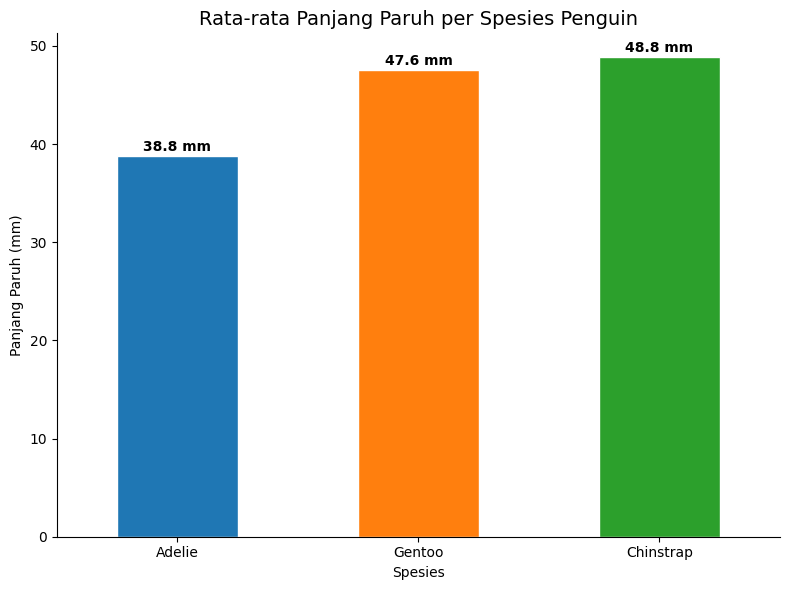

In [3]:
######################################################################
# ── GRAFIK 1: Bar Chart (Rata-rata panjang paruh per spesies) ───────
######################################################################
plt.figure(figsize=(8, 6))

avg_bill_by_species = df.groupby('species')['bill_length_mm'].mean().sort_values()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
avg_bill_by_species.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Rata-rata Panjang Paruh per Spesies Penguin', fontsize=14)
plt.xlabel('Spesies')
plt.ylabel('Panjang Paruh (mm)')
plt.xticks(rotation=0)
plt.gca().spines[['top', 'right']].set_visible(False)


for i, v in enumerate(avg_bill_by_species.values):
    plt.text(i, v + 0.5, f'{v:.1f} mm', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**What?**
Grafik bar chart menunjukkan rata-rata panjang paruh untuk tiga spesies penguin: Adelie (38.8 mm), Chinstrap (48.8 mm), dan Gentoo (47.5 mm). Spesies Chinstrap memiliki paruh terpanjang, disusul Gentoo, sementara Adelie memiliki paruh terpendek dengan selisih sekitar 10 mm dari Chinstrap.

**So what?**
Perbedaan morfologi paruh ini penting karena mencerminkan adaptasi makan yang berbeda. Penguin dengan paruh lebih panjang (Chinstrap dan Gentoo) mungkin memangsa mangsa yang berbeda atau menggunakan teknik menangkap mangsa yang berbeda dibandingkan Adelie.

**Now what?**
Perlu dieksplorasi lebih lanjut apakah panjang paruh berkorelasi dengan kedalaman menyelam atau jenis mangsa utama (krill vs ikan) di masing-masing pulau.

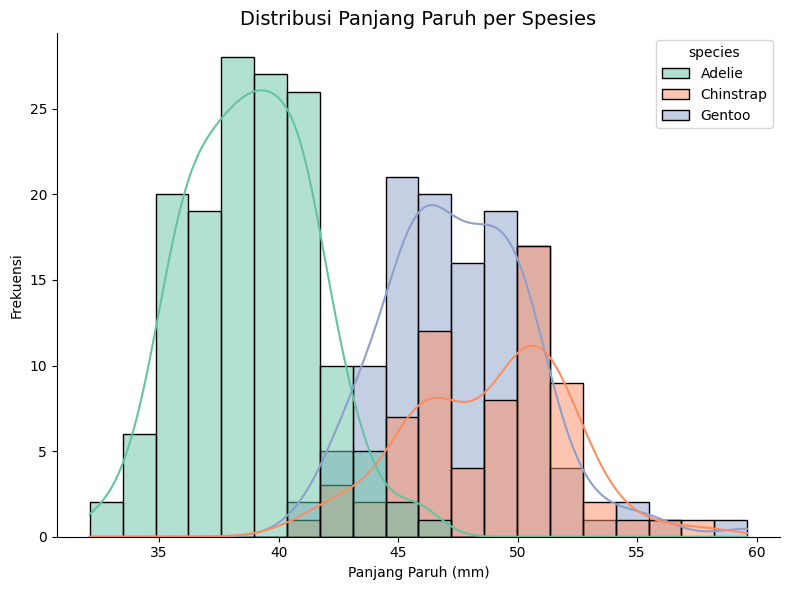

In [4]:
######################################################################
# ── GRAFIK 2: Histogram (Distribusi panjang paruh) ──────────────────
######################################################################
plt.figure(figsize=(8, 6))

sns.histplot(data=df, x='bill_length_mm', hue='species',
             kde=True, palette='Set2', bins=20)
plt.title('Distribusi Panjang Paruh per Spesies', fontsize=14)
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Frekuensi')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**What?**
Histogram dengan KDE menunjukkan tiga puncak distribusi panjang paruh: puncak terendah di sekitar 37-41 mm didominasi spesies Adelie, puncak tengah di 46-50 mm milik Gentoo, dan puncak tertinggi di 48-52 mm milik Chinstrap. Distribusi Adelie paling menyebar (range ~32-46 mm) sementara Chinstrap paling sempit.

**So what?**
Distribusi yang terpisah dengan sedikit tumpang tindih membuktikan bahwa panjang paruh adalah karakteristik yang efektif untuk membedakan spesies. Variabilitas terendah pada Chinstrap menunjukkan seleksi alam yang lebih ketat pada spesies ini.

**Now what?**
Selanjutnya dapat diteliti apakah pola distribusi ini konsisten antara penguin jantan dan betina, mengingat dimorfisme seksual cukup signifikan pada penguin.

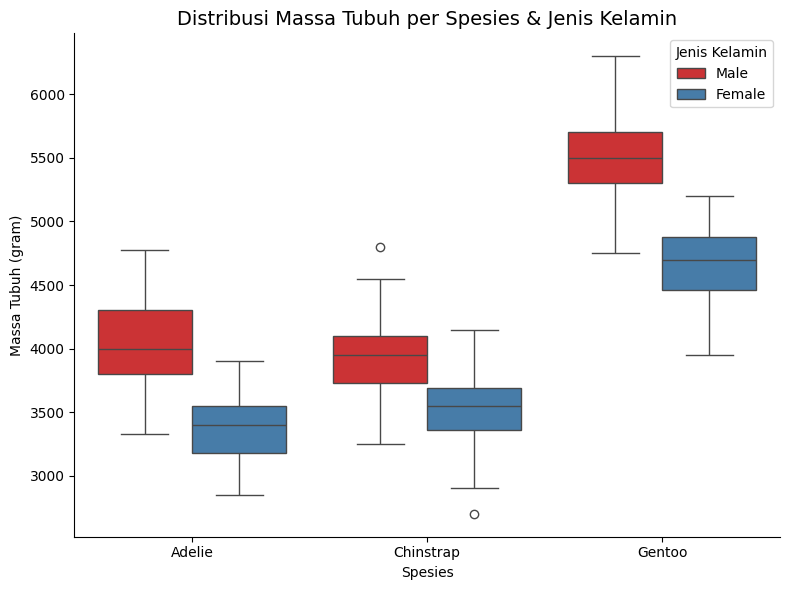

In [5]:
##############################################################################
# ── GRAFIK 3: Boxplot (Distribusi massa tubuh per spesies & jenis kelamin) ──
##############################################################################
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='Set1')
plt.title('Distribusi Massa Tubuh per Spesies & Jenis Kelamin', fontsize=14)
plt.xlabel('Spesies')
plt.ylabel('Massa Tubuh (gram)')
plt.legend(title='Jenis Kelamin')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**What?**
Boxplot menunjukkan massa tubuh berdasarkan spesies dan jenis kelamin. Gentoo adalah spesies terbesar dengan jantan ~5.300g dan betina ~4.600g. Adelie (jantan ~3.800g, betina ~3.400g) dan Chinstrap (jantan ~3.900g, betina ~3.500g) memiliki ukuran yang lebih kecil dan mirip. Pada ketiga spesies, jantan selalu lebih berat dari betina.

**So what?**
Dimorfisme seksual (perbedaan ukuran jantan-betina) terbesar terjadi pada Gentoo dengan selisih sekitar 700 gram. Hal ini mungkin terkait dengan strategi reproduksi, di mana jantan berperan lebih besar dalam kompetisi pasangan atau perlindungan sarang.

**Now what?**
Perlu diuji apakah massa tubuh berkorelasi dengan kesuksesan reproduksi (jumlah anakan yang berhasil hidup) dan apakah pola ini konsisten di setiap pulau.

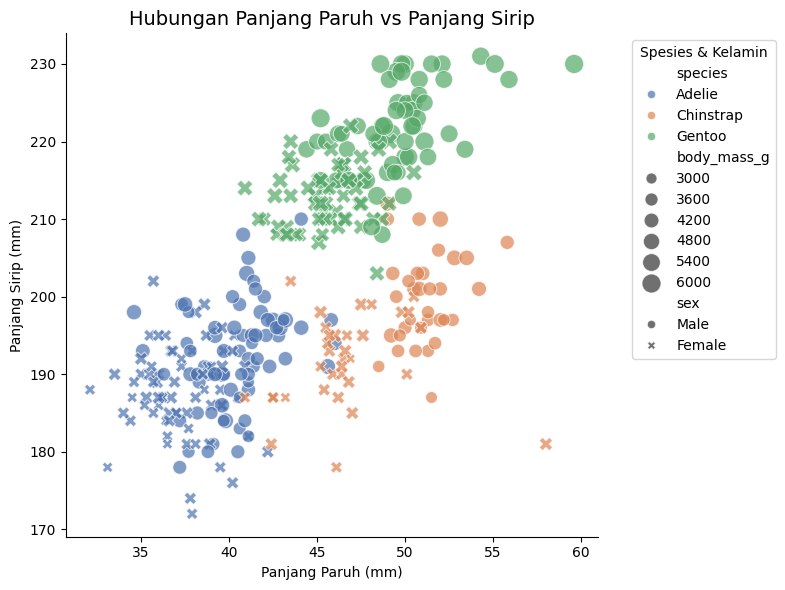

In [6]:
########################################################################
# ── GRAFIK 4: Scatter Plot (Hubungan panjang paruh vs panjang sirip) ──
########################################################################
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', style='sex', size='body_mass_g',
                sizes=(50, 200), palette='deep', alpha=0.7)
plt.title('Hubungan Panjang Paruh vs Panjang Sirip', fontsize=14)
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Panjang Sirip (mm)')
plt.legend(title='Spesies & Kelamin', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**What?**
Scatter plot menunjukkan hubungan positif yang kuat antara panjang paruh dan panjang sirip. Adelie terkonsentrasi di kiri bawah (paruh 34-42 mm, sirip 175-195 mm), Gentoo di kanan bawah (paruh 42-52 mm, sirip 210-230 mm), dan Chinstrap di kanan atas (paruh 46-52 mm, sirip 190-205 mm). Ukuran titik merepresentasikan massa tubuh.

**So what?**
Korelasi positif ini mengindikasikan allometri pertumbuhan yang konsisten: penguin yang lebih besar secara keseluruhan (massa tubuh lebih besar) cenderung memiliki paruh dan sirip yang lebih panjang. Gentoo memiliki sirip terpanjang (hingga 231 mm), cocok untuk berenang cepat mengejar mangsa.

**Now what?**
Selanjutnya dapat dibuat model regresi untuk memprediksi panjang sirip berdasarkan panjang paruh dan spesies, serta menguji apakah rasio paruh:sirip berbeda antar spesies.

Dashboard tersimpan sebagai dashboard_penguins.png


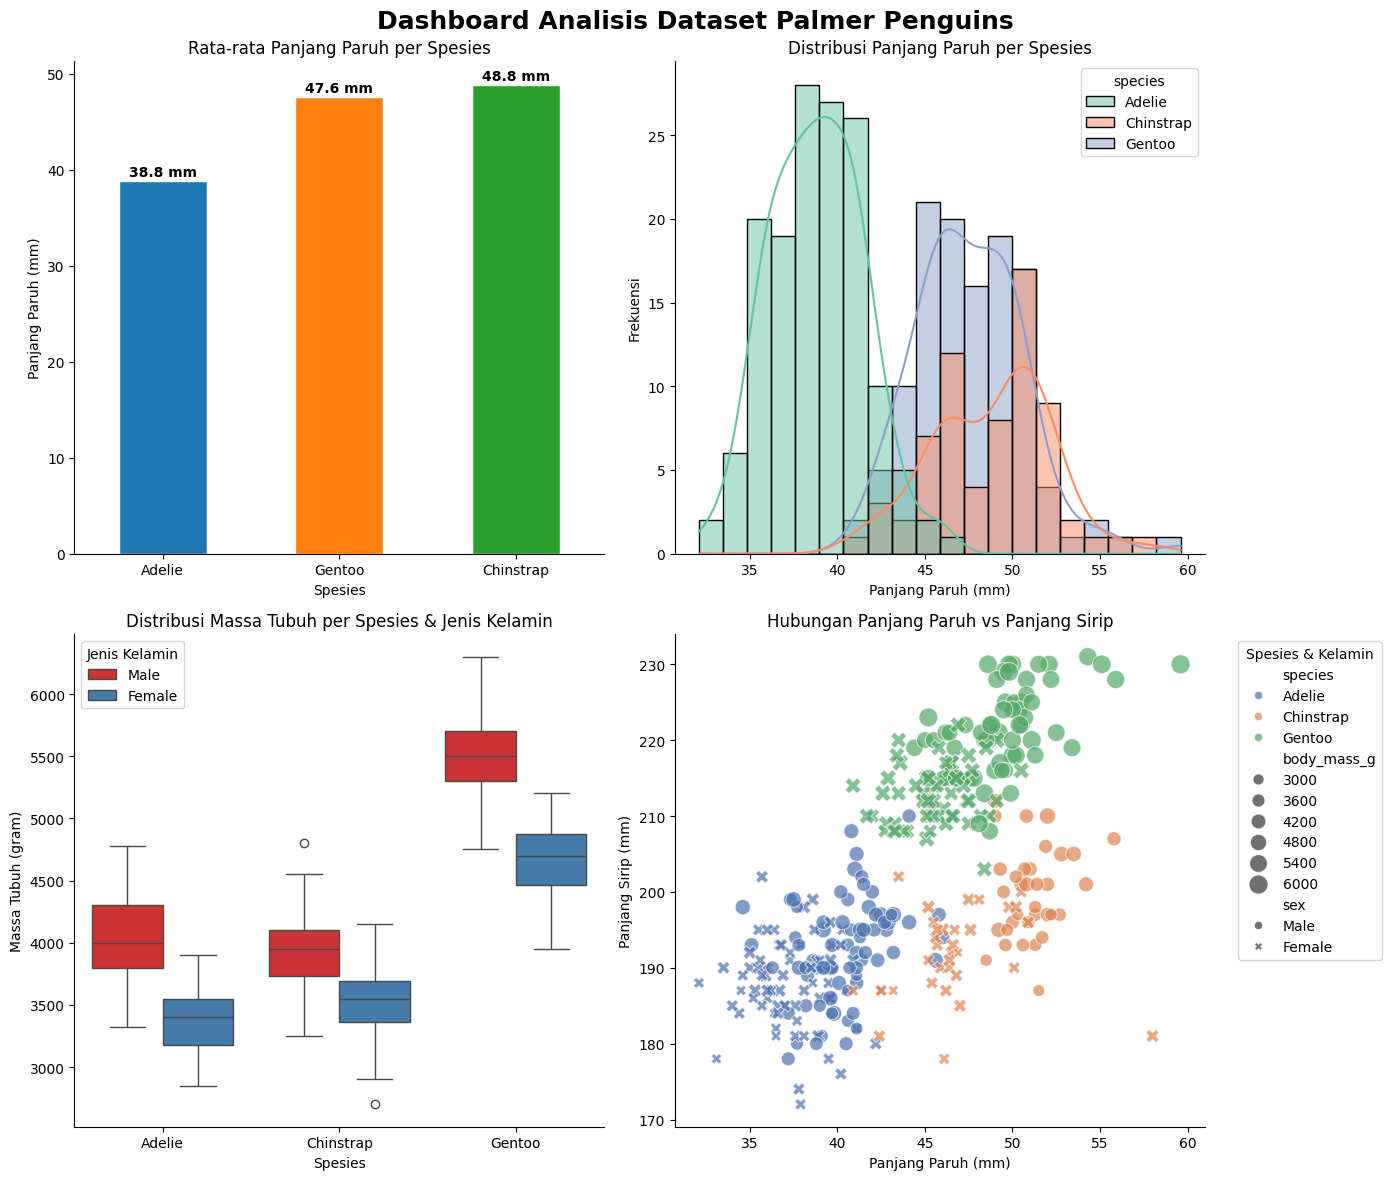

In [7]:
########################################################################
# ── EKSPOR ──────────────────────────────────────────────────
########################################################################
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Dashboard Analisis Dataset Palmer Penguins', fontsize=18, fontweight='bold')

# Grafik 1: Bar Chart
avg_bill_by_species = df.groupby('species')['bill_length_mm'].mean().sort_values()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
avg_bill_by_species.plot(kind='bar', ax=axes[0, 0], color=colors, edgecolor='white')
axes[0, 0].set_title('Rata-rata Panjang Paruh per Spesies')
axes[0, 0].set_xlabel('Spesies')
axes[0, 0].set_ylabel('Panjang Paruh (mm)')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(avg_bill_by_species.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f} mm', ha='center', fontweight='bold')

# Grafik 2: Histogram
sns.histplot(data=df, x='bill_length_mm', hue='species',
             kde=True, palette='Set2', bins=20, ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Panjang Paruh per Spesies')
axes[0, 1].set_xlabel('Panjang Paruh (mm)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Grafik 3: Boxplot
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex',
            palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Distribusi Massa Tubuh per Spesies & Jenis Kelamin')
axes[1, 0].set_xlabel('Spesies')
axes[1, 0].set_ylabel('Massa Tubuh (gram)')
axes[1, 0].legend(title='Jenis Kelamin')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Grafik 4: Scatter Plot
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', style='sex', size='body_mass_g',
                sizes=(50, 200), palette='deep', alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Hubungan Panjang Paruh vs Panjang Sirip')
axes[1, 1].set_xlabel('Panjang Paruh (mm)')
axes[1, 1].set_ylabel('Panjang Sirip (mm)')
axes[1, 1].legend(title='Spesies & Kelamin', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
print('Dashboard tersimpan sebagai dashboard_penguins.png')
plt.show()